In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

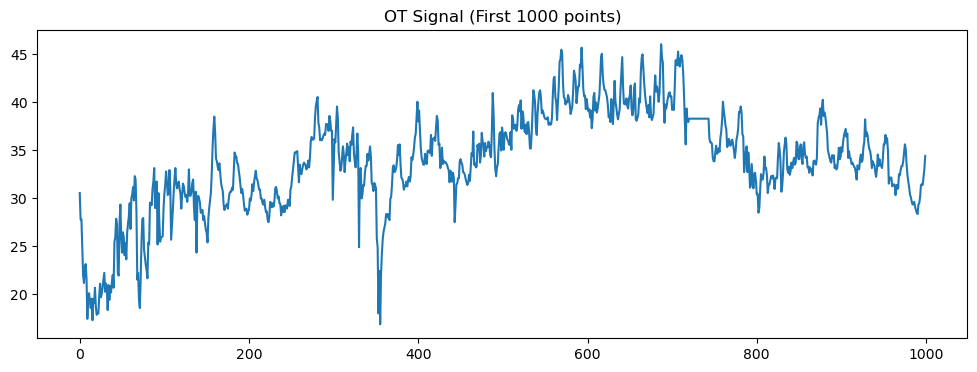

In [2]:
# Load dataset (update path if needed)
df = pd.read_csv("ETTh1.csv")

# Use only OT column
data = df["OT"].values.astype(np.float32)

plt.figure(figsize=(12,4))
plt.plot(data[:1000])
plt.title("OT Signal (First 1000 points)")
plt.show()

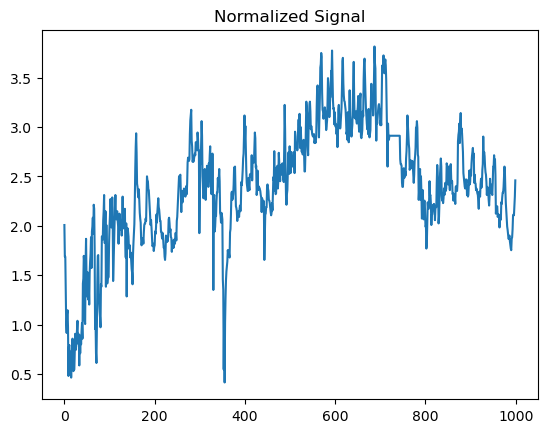

In [3]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1)).flatten()

plt.plot(data_scaled[:1000])
plt.title("Normalized Signal")
plt.show()

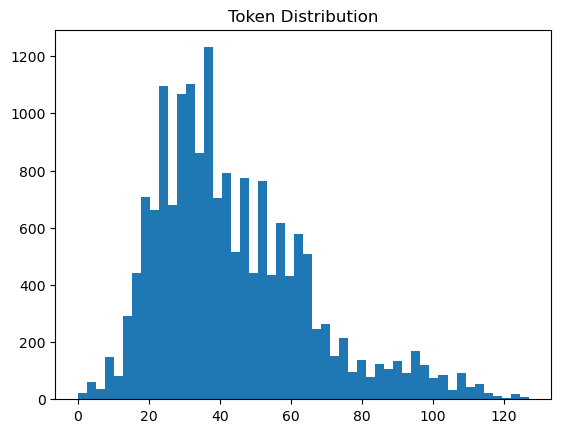

In [4]:
NUM_BINS = 128

# Uniform bins
bin_edges = np.linspace(data_scaled.min(), data_scaled.max(), NUM_BINS + 1)

# Digitize values into bins
tokens = np.digitize(data_scaled, bin_edges) - 1
tokens = np.clip(tokens, 0, NUM_BINS - 1)

plt.hist(tokens, bins=50)
plt.title("Token Distribution")
plt.show()

In [5]:
SEQ_LEN = 96
PRED_LEN = 24

def create_sequences(tokens, seq_len, pred_len):
    X, Y = [], []
    for i in range(len(tokens) - seq_len - pred_len):
        X.append(tokens[i:i+seq_len])
        Y.append(tokens[i+1:i+seq_len+1])  # next-token shift
    return np.array(X), np.array(Y)

X, Y = create_sequences(tokens, SEQ_LEN, PRED_LEN)

print(X.shape, Y.shape)

(17300, 96) (17300, 96)


In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.Y = torch.tensor(Y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = TimeSeriesDataset(X, Y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [7]:
class TokenLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        logits = self.fc(out)
        return logits

model = TokenLSTM(
    vocab_size=NUM_BINS,
    embed_dim=64,
    hidden_dim=128
).to(device)

model

TokenLSTM(
  (embedding): Embedding(128, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=128, bias=True)
)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        
        loss = criterion(
            logits.view(-1, NUM_BINS),
            y.view(-1)
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader):.4f}")

Epoch 1, Loss: 2.5773
Epoch 2, Loss: 1.9367
Epoch 3, Loss: 1.6499
Epoch 4, Loss: 1.3737
Epoch 5, Loss: 1.1553


In [10]:
def sample_sequence(model, start_seq, pred_len):
    model.eval()
    seq = start_seq.clone().to(device)
    
    generated = []
    
    for _ in range(pred_len):
        with torch.no_grad():
            logits = model(seq.unsqueeze(0))
            probs = torch.softmax(logits[0, -1], dim=-1)
            
            next_token = torch.multinomial(probs, 1)
        
        generated.append(next_token.item())
        
        seq = torch.cat([seq[1:], next_token])
    
    return generated

In [11]:
def tokens_to_values(tokens):
    values = []
    for t in tokens:
        bin_center = (bin_edges[t] + bin_edges[t+1]) / 2
        values.append(bin_center)
    return scaler.inverse_transform(np.array(values).reshape(-1,1)).flatten()

In [12]:
# Pick a random example
idx = np.random.randint(0, len(X))

input_seq = torch.tensor(X[idx], dtype=torch.long)
true_future = tokens_to_values(Y[idx])

generated_tokens = sample_sequence(model, input_seq, PRED_LEN)
generated_values = tokens_to_values(generated_tokens)

history_values = tokens_to_values(X[idx])

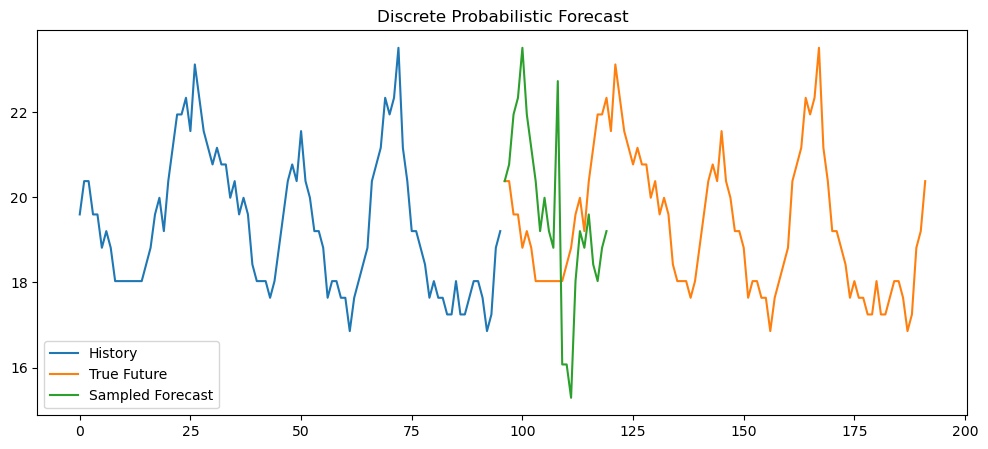

In [13]:
plt.figure(figsize=(12,5))

plt.plot(range(len(history_values)), history_values, label="History")
plt.plot(range(len(history_values), len(history_values)+len(true_future)), true_future, label="True Future")
plt.plot(range(len(history_values), len(history_values)+len(generated_values)), generated_values, label="Sampled Forecast")

plt.legend()
plt.title("Discrete Probabilistic Forecast")
plt.show()

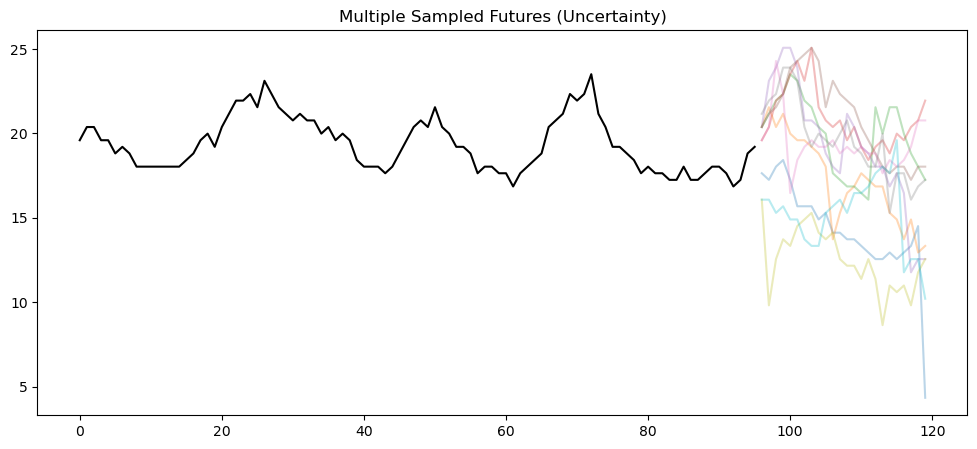

In [14]:
plt.figure(figsize=(12,5))

for _ in range(10):
    gen_tokens = sample_sequence(model, input_seq, PRED_LEN)
    gen_values = tokens_to_values(gen_tokens)
    
    plt.plot(range(len(history_values), len(history_values)+len(gen_values)), gen_values, alpha=0.3)

plt.plot(range(len(history_values)), history_values, label="History", color="black")
plt.title("Multiple Sampled Futures (Uncertainty)")
plt.show()